<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
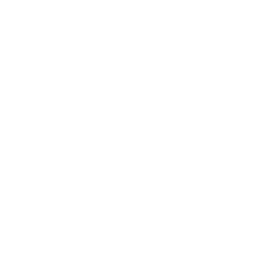
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Documentation du schéma d'annotation de variants génomiques</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bio-informatique / Gestion des données de génomique clinique &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé

Documenter le schéma des jeux de données d'annotation de variants de type VCF utilisés dans un pipeline de génomique clinique. Utiliser PROC CONTENTS pour cataloguer tous les champs d'annotation — coordonnées génomiques, fréquences alléliques, effets fonctionnels prédits, classifications ClinVar et métriques de qualité — en s'assurant que les outils d'interprétation de variants ACMG en aval reçoivent des entrées correctement typées et libellées. Environ 5 000 enregistrements de variants comportant plus de 20 colonnes d'annotation sont inspectés pour l'intégrité du schéma avant le transfert au pipeline.

## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Variants annotés dérivés de VCF | ~5 000 |
| GENE_PANEL | Définitions du panel de gènes cibles | ~150 gènes |
| QUALITY_METRICS | Contrôle qualité du séquençage par échantillon | ~50 échantillons |

---

In [1]:
/* --------------------------------------------------------
   Générer un jeu de données d'annotation de variants façon VCF
   5 000 variants avec des champs d'annotation clinique
   -------------------------------------------------------- */
DONNÉES variant_annotations;
    APPELER streaminit(42);
    LONGUEUR variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    ÉTIQUETTE variant_id='Identifiant de variant'
          chromosome='Chromosome'
          position='Position génomique (GRCh38)'
          ref_allele='Allèle de référence'
          alt_allele='Allèle alternatif'
          gene_symbol='Symbole de gène HGNC'
          transcript_id='ID de transcrit Ensembl'
          consequence='Conséquence Sequence Ontology'
          impact="Niveau d'impact prédit"
          hgvs_c='Notation codante HGVS'
          hgvs_p='Notation protéique HGVS'
          gnomad_af='Fréquence allélique gnomAD'
          clinvar_class='Classification ClinVar'
          clinvar_id='Numéro ClinVar'
          sift_score='Score SIFT'
          sift_pred='Prédiction SIFT'
          polyphen_score='Score PolyPhen-2'
          polyphen_pred='Prédiction PolyPhen-2'
          cadd_phred='Score Phred CADD'
          revel_score="Score d'ensemble REVEL"
          genotype="Génotype de l'échantillon"
          allele_depth="Profondeur de l'allèle alternatif"
          read_depth='Profondeur de lecture totale'
          qual_score='Score de qualité du variant'
          filter_status='Statut du filtre';
    TABLEAU genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TABLEAU conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    TABLEAU impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    TABLEAU cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    TABLEAU refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    TABLEAU gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    FAIRE i = 1 JUSQU_À 5000;
        variant_id = cat('VAR-', ÉCRIRE(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', ÉCRIRE(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', ÉCRIRE(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', ÉCRIRE(codon_pos, 4.), ref_allele, '>', alt_allele);
        SI c_idx <= 2 ALORS
            hgvs_p = cat('p.', ÉCRIRE(int(rand('uniform') * 800) + 1, 4.));
        SINON hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', ÉCRIRE(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        SI sift_score < 0.05 ALORS sift_pred = 'DELETERIOUS';
        SINON sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        SI polyphen_score > 0.908 ALORS polyphen_pred = 'PROB_DAMAGING';
        SINON SI polyphen_score > 0.446 ALORS polyphen_pred = 'POSS_DAMAGING';
        SINON polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        SORTIE;
    FIN;
    SUPPRIMER i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
EXÉCUTER;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.10 seconds
  cpu   3.10 seconds


In [2]:
/* --------------------------------------------------------
   Générer les définitions du panel de gènes cible
   -------------------------------------------------------- */
DONNÉES gene_panel;
    APPELER streaminit(42);
    LONGUEUR gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    ÉTIQUETTE gene_symbol='Symbole de gène HGNC'
          gene_name='Nom complet du gène'
          chromosome='Chromosome'
          start_pos='Position de début du gène'
          end_pos='Position de fin du gène'
          panel_name='Panel de gènes clinique'
          disease_association='Maladie associée'
          inheritance='Mode de transmission';
    TABLEAU genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TABLEAU gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    TABLEAU diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    TABLEAU inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    FAIRE g = 1 JUSQU_À 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', ÉCRIRE(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        SORTIE;
    FIN;
    SUPPRIMER g chr_num;
EXÉCUTER;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Générer les métriques de qualité de séquençage par échantillon
   -------------------------------------------------------- */
DONNÉES quality_metrics;
    APPELER streaminit(42);
    LONGUEUR sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    ÉTIQUETTE sample_id="Identifiant d'échantillon"
          run_id='ID de run de séquençage'
          platform='Plateforme de séquençage'
          mean_coverage='Couverture cible moyenne'
          pct_target_20x='Pourcentage de bases >= 20x'
          pct_target_100x='Pourcentage de bases >= 100x'
          total_variants='Total de variants appelés'
          ti_tv_ratio='Ratio transition/transversion'
          het_hom_ratio='Ratio hét/hom'
          contamination_est='Contamination estimée'
          qc_status='Statut de réussite/échec du CQ';
    FAIRE s = 1 JUSQU_À 50;
        sample_id = cat('SAMP-', ÉCRIRE(s, z6.));
        run_id = cat('RUN-', ÉCRIRE(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        SI mean_coverage < 150 OU pct_target_20x < 95
            OU contamination_est > 0.015 ALORS qc_status = 'FAIL';
        SINON qc_status = 'PASS';
        SORTIE;
    FIN;
    SUPPRIMER s;
EXÉCUTER;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                     Impact des variants par classification ClinVar                                     

                                                   The FREQ Procedure

Table of Niveau d'impact prédit by Classification ClinVar

Niveau d'impact prédit  |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                    |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                        |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                        |                 14.52 |                 16.13 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


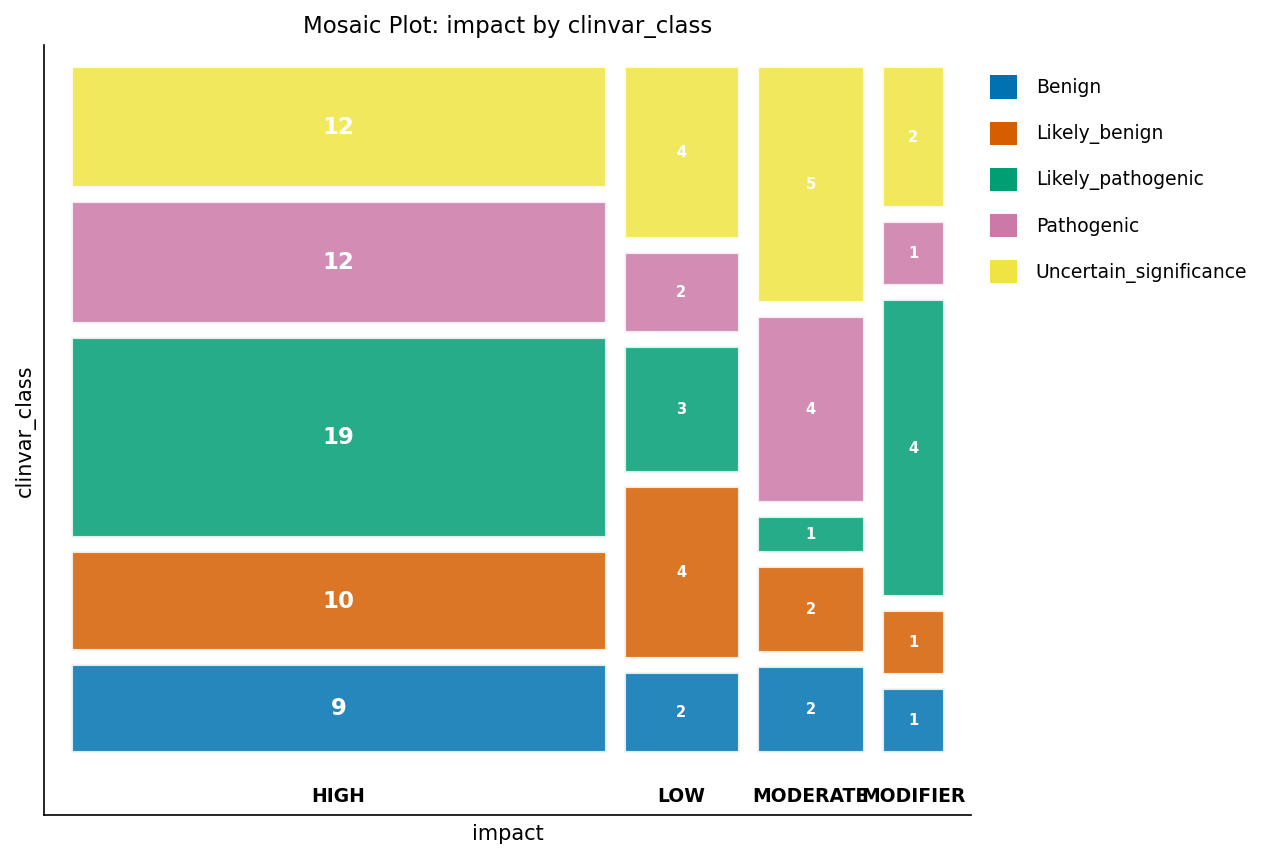

In [4]:
/* --------------------------------------------------------
   Synthèse de référence de l'annotation des variants
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    TITRE 'Impact des variants par classification ClinVar';
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=quality_metrics n mean MIN MAX;
    VAR mean_coverage ti_tv_ratio contamination_est;
    TITRE 'Synthèse des métriques de qualité de séquençage';
EXÉCUTER;

---

                                    Synthèse des métriques de qualité de séquençage                                     

                                    Synthèse des métriques de qualité de séquençage                                     




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


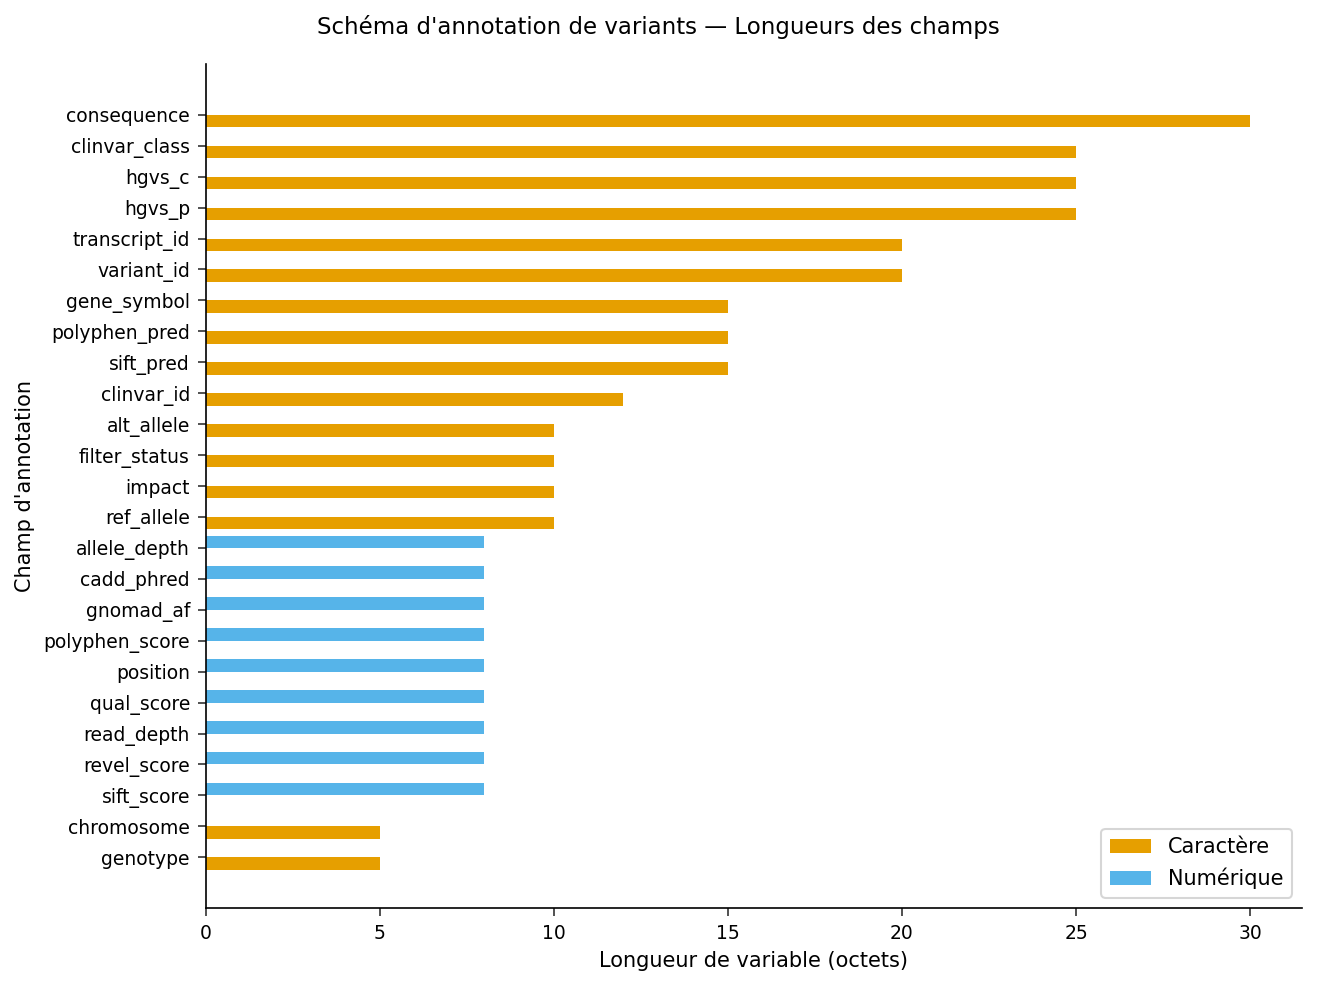

In [5]:
/* --------------------------------------------------------
   Distribution des types et longueurs de variables.
   Capture les métadonnées du schéma d'annotation avec
   PROC CONTENTS OUT=, puis trace les longueurs de champs
   par type. Les codes TYPE : 1 -> Numérique, 2 -> Caractère
   pour la légende.
   -------------------------------------------------------- */
PROCÉDURE CONTENU DONNÉES=variant_annotations out=schema_lengths SANS_IMPRESSION;
EXÉCUTER;

DONNÉES schema_lengths;
    DÉFINIR schema_lengths;
    LONGUEUR type_label $16;
    SI TYPE = 1 ALORS type_label = 'Numérique';
    SINON type_label = 'Caractère';
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=schema_lengths;
    HBAR NAME / RESPONSE=LONGUEUR GROUPE=type_label
        CATEGORYORDER=respdesc;
    XAXIS ÉTIQUETTE='Longueur de variable (octets)';
    YAXIS ÉTIQUETTE="Champ d'annotation";
    TITRE "Schéma d'annotation de variants — Longueurs des champs";
EXÉCUTER;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS : documenter le schéma complet d'annotation
   des variants — types, longueurs, libellés des 25 champs.
   Capture les métadonnées des variables avec OUT= afin que
   les étapes en aval puissent valider le schéma par programme.
   -------------------------------------------------------- */
PROCÉDURE CONTENU DONNÉES=variant_annotations out=variant_schema SANS_IMPRESSION;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=variant_schema ÉTIQUETTE;
    VAR NAME TYPE LONGUEUR VARNUM ÉTIQUETTE;
    ÉTIQUETTE NAME='Nom' TYPE='Type' LONGUEUR='Longueur'
          VARNUM='Position var.' ÉTIQUETTE='Libellé';
    TITRE "Jeu de données d'annotation de variants — Schéma complet";
EXÉCUTER;

                                    Synthèse des métriques de qualité de séquençage                                     

                                Jeu de données d'annotation de variants — Schéma complet                                

  Obs             Nom  Type  Longueur  Position var.                             Libellé
    1  allele_depth       1         8             22  Profondeur de l'allèle alternatif
    2  alt_allele         2        10              5  Allèle alternatif
    3  cadd_phred         1         8             19  Score Phred CADD
    4  chromosome         2         5              2  Chromosome
    5  clinvar_class      2        25             13  Classification ClinVar
    6  clinvar_id         2        12             14  Numéro ClinVar
    7  consequence        2        30              8  Conséquence Sequence Ontology
    8  filter_status      2        10             25  Statut du filtre
    9  gene_symbol        2        15              6  Symbole de gène 


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS : documenter le schéma du panel de gènes
   -------------------------------------------------------- */
PROCÉDURE CONTENU DONNÉES=gene_panel out=panel_schema SANS_IMPRESSION;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=panel_schema ÉTIQUETTE;
    VAR NAME TYPE LONGUEUR VARNUM ÉTIQUETTE;
    ÉTIQUETTE NAME='Nom' TYPE='Type' LONGUEUR='Longueur'
          VARNUM='Position var.' ÉTIQUETTE='Libellé';
    TITRE 'Définition du panel de gènes — Schéma';
EXÉCUTER;

                                Jeu de données d'annotation de variants — Schéma complet                                

                                         Définition du panel de gènes — Schéma                                          

  Obs                  Nom  Type  Longueur  Position var.                      Libellé
    1  chromosome              2         5              3  Chromosome
    2  disease_association     2        50              7  Maladie associée
    3  end_pos                 1         8              5  Position de fin du gène
    4  gene_name               2        60              2  Nom complet du gène
    5  gene_symbol             2        15              1  Symbole de gène HGNC
    6  inheritance             2         5              8  Mode de transmission
    7  panel_name              2        30              6  Panel de gènes clinique
    8  start_pos               1         8              4  Position de début du gène




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS : documenter le schéma des métriques de CQ
   -------------------------------------------------------- */
PROCÉDURE CONTENU DONNÉES=quality_metrics out=qc_schema SANS_IMPRESSION;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=qc_schema ÉTIQUETTE;
    VAR NAME TYPE LONGUEUR VARNUM ÉTIQUETTE;
    ÉTIQUETTE NAME='Nom' TYPE='Type' LONGUEUR='Longueur'
          VARNUM='Position var.' ÉTIQUETTE='Libellé';
    TITRE 'Métriques de qualité de séquençage — Schéma';
EXÉCUTER;

                                         Définition du panel de gènes — Schéma                                          

                                      Métriques de qualité de séquençage — Schéma                                       

  Obs                Nom  Type  Longueur  Position var.                           Libellé
    1  contamination_est     1         8             10  Contamination estimée
    2  het_hom_ratio         1         8              9  Ratio hét/hom
    3  mean_coverage         1         8              4  Couverture cible moyenne
    4  pct_target_100x       1         8              6  Pourcentage de bases >= 100x
    5  pct_target_20x        1         8              5  Pourcentage de bases >= 20x
    6  platform              2        15              3  Plateforme de séquençage
    7  qc_status             2        10             11  Statut de réussite/échec du CQ
    8  run_id                2        12              2  ID de run de séquençage
    9  sampl


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Validation du schéma : vérifier que les champs d'annotation
   satisfont aux exigences du pipeline pour l'interprétation ACMG.
   Lit les métadonnées de PROC CONTENTS OUT=, où TYPE=1 désigne
   le numérique et TYPE=2 le caractère.
   -------------------------------------------------------- */
DONNÉES schema_validation;
    DÉFINIR variant_schema;
    LONGUEUR requirement $80 status $16;
    /* Les champs de score numériques doivent être stockés en numérique (TYPE=1) */
    SI NAME DANS ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 ALORS FAIRE;
        requirement = 'Doit être numérique pour les seuils de score';
        status = 'ÉCHEC';
    FIN;
    SINON SI NAME DANS ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 ALORS FAIRE;
        requirement = 'Type numérique confirmé';
        status = 'RÉUSSITE';
    FIN;
    /* La classe ClinVar nécessite une longueur de caractères suffisante */
    SINON SI NAME = 'clinvar_class' AND LONGUEUR < 25 ALORS FAIRE;
        requirement = 'Min. $25 pour le texte de classification complet';
        status = 'ÉCHEC';
    FIN;
    SINON SI NAME = 'clinvar_class' ALORS FAIRE;
        requirement = 'Longueur de caractères suffisante';
        status = 'RÉUSSITE';
    FIN;
    /* Tous les champs doivent porter un libellé pour le dictionnaire de données */
    SINON SI ÉTIQUETTE = '' ALORS FAIRE;
        requirement = 'Libellé requis pour le dictionnaire de données';
        status = 'ÉCHEC';
    FIN;
    SINON FAIRE;
        requirement = 'Validation générale';
        status = 'RÉUSSITE';
    FIN;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=schema_validation ÉTIQUETTE;
    VAR NAME TYPE LONGUEUR ÉTIQUETTE requirement status;
    ÉTIQUETTE NAME='Nom' TYPE='Type' LONGUEUR='Longueur' ÉTIQUETTE='Libellé'
          requirement='Exigence' status='Statut';
    TITRE 'Rapport de validation du schéma pour le pipeline ACMG';
EXÉCUTER;

                                 Rapport de validation du schéma pour le pipeline ACMG                                  

  Obs             Nom  Type  Longueur                             Libellé                            Exigence     Statut
    1  allele_depth       1         8  Profondeur de l'allèle alternatif   Type numérique confirmé             RÉUSSITE
    2  alt_allele         2        10  Allèle alternatif                   Validation générale                 RÉUSSITE
    3  cadd_phred         1         8  Score Phred CADD                    Type numérique confirmé             RÉUSSITE
    4  chromosome         2         5  Chromosome                          Validation générale                 RÉUSSITE
    5  clinvar_class      2        25  Classification ClinVar              Longueur de caractères suffisante   RÉUSSITE
    6  clinvar_id         2        12  Numéro ClinVar                      Validation générale                 RÉUSSITE
    7  consequence        2        30


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interprétation

Le schéma d'annotation de variants contient 25 champs couvrant les coordonnées génomiques, les prédictions fonctionnelles, les fréquences dans la population et les indicateurs de qualité par échantillon. Les neuf champs de score numériques (fréquence allélique gnomAD, SIFT, PolyPhen-2, CADD, REVEL, score de qualité, profondeur d'allèle, profondeur de lecture et position génomique) sont correctement typés comme numériques, ce qui permet au moteur d'interprétation ACMG d'appliquer un filtrage par seuil sans conversion de type. Le champ clinvar_class à $25 accommode la plus longue chaîne de classification ClinVar (Uncertain_significance, 24 caractères). Chaque champ d'annotation porte un libellé descriptif, satisfaisant l'exigence de dictionnaire de données du laboratoire clinique au titre des exigences d'accréditation CAP. Le schéma du panel de gènes cartographie 15 gènes de prédisposition au cancer avec leurs modes de transmission et associations pathologiques, fournissant le cadre de référence pour l'annotation variant-vers-gène. Le jeu de données de métriques de contrôle qualité du séquençage documente 50 échantillons répartis sur 5 exécutions, avec des estimations de contamination et des seuils de couverture qui conditionnent la fiabilité de l'appel de variants. Ce dossier de documentation du schéma soutient le dossier de validation du laboratoire pour la soumission CLEP de l'État de New York.

---

In [10]:
/* --------------------------------------------------------
   Exporter la documentation du schéma de variants et le
   rapport de validation pour l'accréditation du laboratoire
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>